# How Rare Is 100°F in Washington, DC?
### A Climate Attribution Analysis of the July 2026 Heat Event at KDCA

On June 25, 2026, the GFS operational forecast showed 2-m temperatures approaching **38°C (100°F)** at Reagan National Airport (KDCA) around July 2–3. That's a striking number for a mid-Atlantic city, even in the middle of summer.

This notebook asks two questions:

1. **How rare is a 38°C day at KDCA** in today's climate, based on 53 years of observations?
2. **How much did anthropogenic warming change the odds** of this event compared to a pre-industrial baseline?

The analysis uses only station observations and reanalysis — no climate model output. That limits the precision of the attribution (confidence intervals are wide with 53 years of data), but it keeps the methodology transparent and reproducible from public data sources.

---
*Data: NOAA ASOS hourly (KDCA, 1973–2025) · NOAA GFS (init: 2026-06-27 00Z) · NASA GISTEMP v4*  
*Method: Philip et al. (2020), Adv. in Statistical Climatology, Meteorology and Oceanography, 6, 177–203*  
*Attribution framework: Stott et al. (2004), Nature, 432, 610–614*

In [1]:
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import genextreme
from scipy.optimize import minimize

# Paths — notebook lives at analyses/dc_heatwave_2026/, data at repo root /data/
REPO_ROOT = Path('../..').resolve()
DATA_DIR  = REPO_ROOT / 'data'
ASOS_DIR  = DATA_DIR / 'asos_cache'
GFS_PATH  = DATA_DIR / 'dc_heatwave_forecast_20260627_0000Z_forecast.nc'
FIG_DIR   = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

KDCA_LAT, KDCA_LON = 38.9072, -77.0369

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.dpi':        150,
    'figure.figsize':    (12.0, 5.0),
    'font.family':       'sans-serif',
    'font.size':         13,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'lines.linewidth':   2.0,
    'legend.frameon':    False,
})

## 1. Data

**Observations:** NOAA ASOS hourly surface data at KDCA (Reagan National Airport), fetched from the Iowa State Mesonet archive. I concatenate all available years (1973–2025) and sort chronologically.

**Forecast:** NOAA GFS 0.25° operational run initialized 2026-06-27 00Z, fetched via [Herbie](https://herbie.readthedocs.io/) from the NOAA AWS archive and cached locally as NetCDF. I extract the 2-m temperature time series at the grid point nearest to KDCA (lon convention: 0–360°).

> Data is not included in this repository. ASOS data can be retrieved from the [Iowa State Mesonet](https://mesonet.agron.iastate.edu/); GFS forecasts via Herbie (`model='gfs'`, `date='2026-06-27'`, `fxx=range(48, 193, 6)`).

In [2]:
# ASOS hourly observations — concatenate cached CSVs
frames = []
for f in sorted(ASOS_DIR.glob('KDCA_*.csv')):
    df = pd.read_csv(f, parse_dates=['valid_utc'])
    frames.append(df)

kdca_all = pd.concat(frames, ignore_index=True)
kdca_all['valid_utc'] = pd.to_datetime(kdca_all['valid_utc'], utc=True)
kdca_all = kdca_all.sort_values('valid_utc').reset_index(drop=True)

# GFS forecast — 2026-06-27 00Z, covers Jun 29 – Jul 5
ds_gfs = xr.open_dataset(GFS_PATH)

print(f'KDCA: {len(kdca_all):,} hourly obs  ({kdca_all.valid_utc.dt.year.min()}–{kdca_all.valid_utc.dt.year.max()})')
print(f'GFS:  {GFS_PATH.name}')
print(f'      time range: {str(ds_gfs.time.values[0])[:16]} → {str(ds_gfs.time.values[-1])[:16]}')

KDCA: 458,807 hourly obs  (1973–2025)
GFS:  dc_heatwave_forecast_20260627_0000Z_forecast.nc
      time range: 2026-06-29T00:00 → 2026-07-05T00:00


## 2. The Historical Record — Annual JJA Block Maxima

To build a baseline for rarity, I extract one value per year: the highest daily maximum temperature during June, July, or August. This is the **annual JJA block maximum**.

Restricting to JJA keeps the sample physically homogeneous — the same synoptic regime, similar boundary layer conditions, consistent land surface forcing. Using annual block maxima (rather than all exceedances above some threshold) guarantees year-to-year independence and aligns with the Fisher–Tippett–Gnedenko theorem, which establishes the GEV as the limiting distribution of block maxima.

The KDCA record runs 1973–2025 — 53 years of data.

In [3]:
jja_mask = kdca_all['valid_utc'].dt.month.isin([6, 7, 8])
ann_max  = kdca_all.loc[jja_mask].groupby(
    kdca_all.loc[jja_mask, 'valid_utc'].dt.year
)['temp_c'].max()

print(f'n = {len(ann_max)} years  ({ann_max.index[0]}–{ann_max.index[-1]})')
print(f'Range: {ann_max.min():.1f}–{ann_max.max():.1f}°C')
print(f'\nTop 10 hottest JJA years at KDCA:')
print(ann_max.sort_values(ascending=False).head(10).to_string())

n = 53 years  (1973–2025)
Range: 33.0–40.6°C

Top 10 hottest JJA years at KDCA:
valid_utc
2012    40.555556
1980    39.444444
2024    39.444444
1988    39.444444
2011    39.444444
1997    39.000000
1999    38.888889
2010    38.888889
1983    38.333333
1991    38.333333


## 3. Fitting a Stationary GEV

The **Generalized Extreme Value (GEV) distribution** is the natural model for annual block maxima. Its three parameters each describe something physically meaningful:

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| Location | μ | Center of the distribution — roughly the "typical" annual maximum |
| Scale | σ | Year-to-year spread |
| Shape | ξ | Tail behavior: ξ < 0 → finite upper bound (Weibull), ξ = 0 → exponential, ξ > 0 → heavy tail |

I fit by maximum likelihood. One note on conventions: `scipy.stats.genextreme` uses `c = ξ` with the sign already folded in, so a negative `c` value (what you get for DC) corresponds to a **Weibull tail** in Coles (2001) notation — the distribution has a physical upper bound.

**Return levels** follow from the inverse CDF. The T-year return level is the temperature exceeded with probability 1/T in any given year. Equivalently, it has an average recurrence interval of T years — though it's worth noting this says nothing about spacing between events (a 10-year event can happen twice in a row).

Bootstrap confidence intervals (500 resamples with replacement) propagate parameter uncertainty into the return level estimates.

In [4]:
c, loc, scale = genextreme.fit(ann_max, method='MLE')

print('Stationary GEV parameters:')
print(f'  μ (location) = {loc:.2f}°C')
print(f'  σ (scale)    = {scale:.2f}°C')
print(f'  ξ (shape)    = {-c:.3f}  → Weibull tail, finite upper bound')

return_10 = genextreme.ppf(1 - 1/10,  c, loc, scale)
return_50 = genextreme.ppf(1 - 1/50,  c, loc, scale)

np.random.seed(42)
boot_10, boot_50 = [], []
for _ in range(500):
    sample       = np.random.choice(ann_max, size=len(ann_max), replace=True)
    c_b, l_b, s_b = genextreme.fit(sample, method='MLE')
    boot_10.append(genextreme.ppf(1 - 1/10, c_b, l_b, s_b))
    boot_50.append(genextreme.ppf(1 - 1/50, c_b, l_b, s_b))

ci_10 = (np.percentile(boot_10, 2.5), np.percentile(boot_10, 97.5))
ci_50 = (np.percentile(boot_50, 2.5), np.percentile(boot_50, 97.5))

print(f'\nReturn levels:')
print(f'  10-yr: {return_10:.1f}°C  [{ci_10[0]:.1f}, {ci_10[1]:.1f}]')
print(f'  50-yr: {return_50:.1f}°C  [{ci_50[0]:.1f}, {ci_50[1]:.1f}]')

Stationary GEV parameters:
  μ (location) = 36.20°C
  σ (scale)    = 1.58°C
  ξ (shape)    = -0.266  → Weibull tail, finite upper bound

Return levels:
  10-yr: 38.9°C  [38.2, 39.3]
  50-yr: 40.0°C  [39.2, 40.8]


**Parameters make physical sense.** μ = 36.2°C is where the distribution is centered — the typical annual maximum. σ = 1.58°C captures year-to-year variability driven by interannual differences in circulation and soil moisture. The Weibull shape (ξ = −0.27) means DC summer extremes can't grow without limit, which is physically reasonable: the boundary layer, land surface, and synoptic flow all impose constraints on how hot it can get.

**CI width reflects data availability.** The 10-yr CI [38.2, 39.3] is 1.1°C wide — we've observed several 10-year events in 53 years. The 50-yr CI [39.2, 40.8] is 1.6°C wide — at that frequency, we've barely sampled the tail. The frequentist interpretation: if this study were repeated many times with different 53-year records from the same true distribution, 95% of the intervals would contain the true return level.

## 4. The GFS Forecast in Context

In [5]:
# GFS 2-m temperature at the nearest grid point to KDCA
kdca_ts = (ds_gfs['t2m']
           .sel(latitude=KDCA_LAT, longitude=KDCA_LON % 360, method='nearest')
           - 273.15)
kdca_tf = kdca_ts * 9/5 + 32

gfs_peak_c    = float(kdca_ts.max().values)
gfs_peak_f    = float(kdca_tf.max().values)
gfs_peak_time = kdca_ts.idxmax('time').values

# Stationary return period for the GFS peak
exceedance = genextreme.sf(gfs_peak_c, c, loc, scale)
gfs_rp     = 1 / exceedance

# Historical percentile envelope for the forecast window (±7 day DOY pooling)
kdca_all['valid_local'] = kdca_all['valid_utc'].dt.tz_convert('America/New_York')
kdca_all_daily = kdca_all.set_index('valid_local').resample('1D')['temp_c'].max()
kdca_ts_daily  = kdca_ts.resample(time='1D').max()

p10, p50, p90, dates = [], [], [], []
for day in pd.to_datetime(kdca_ts_daily.time.values):
    doy      = day.day_of_year
    doy_hist = kdca_all_daily.index.day_of_year
    diff     = np.minimum(np.abs(doy_hist - doy), 365 - np.abs(doy_hist - doy))
    pool     = kdca_all_daily[diff <= 7]
    if len(pool) < 20:
        continue
    dates.append(day)
    p10.append(pool.quantile(0.1))
    p50.append(pool.quantile(0.5))
    p90.append(pool.quantile(0.9))

env = pd.DataFrame({'date': dates, 'p10': p10, 'p50': p50, 'p90': p90})

print(f'GFS peak: {gfs_peak_c:.1f}°C ({gfs_peak_f:.1f}°F)  on {pd.Timestamp(gfs_peak_time).strftime("%b %d %H UTC")}')
print(f'Stationary return period: ~{gfs_rp:.0f} years')

GFS peak: 38.1°C (100.6°F)  on Jul 02 18 UTC
Stationary return period: ~5 years


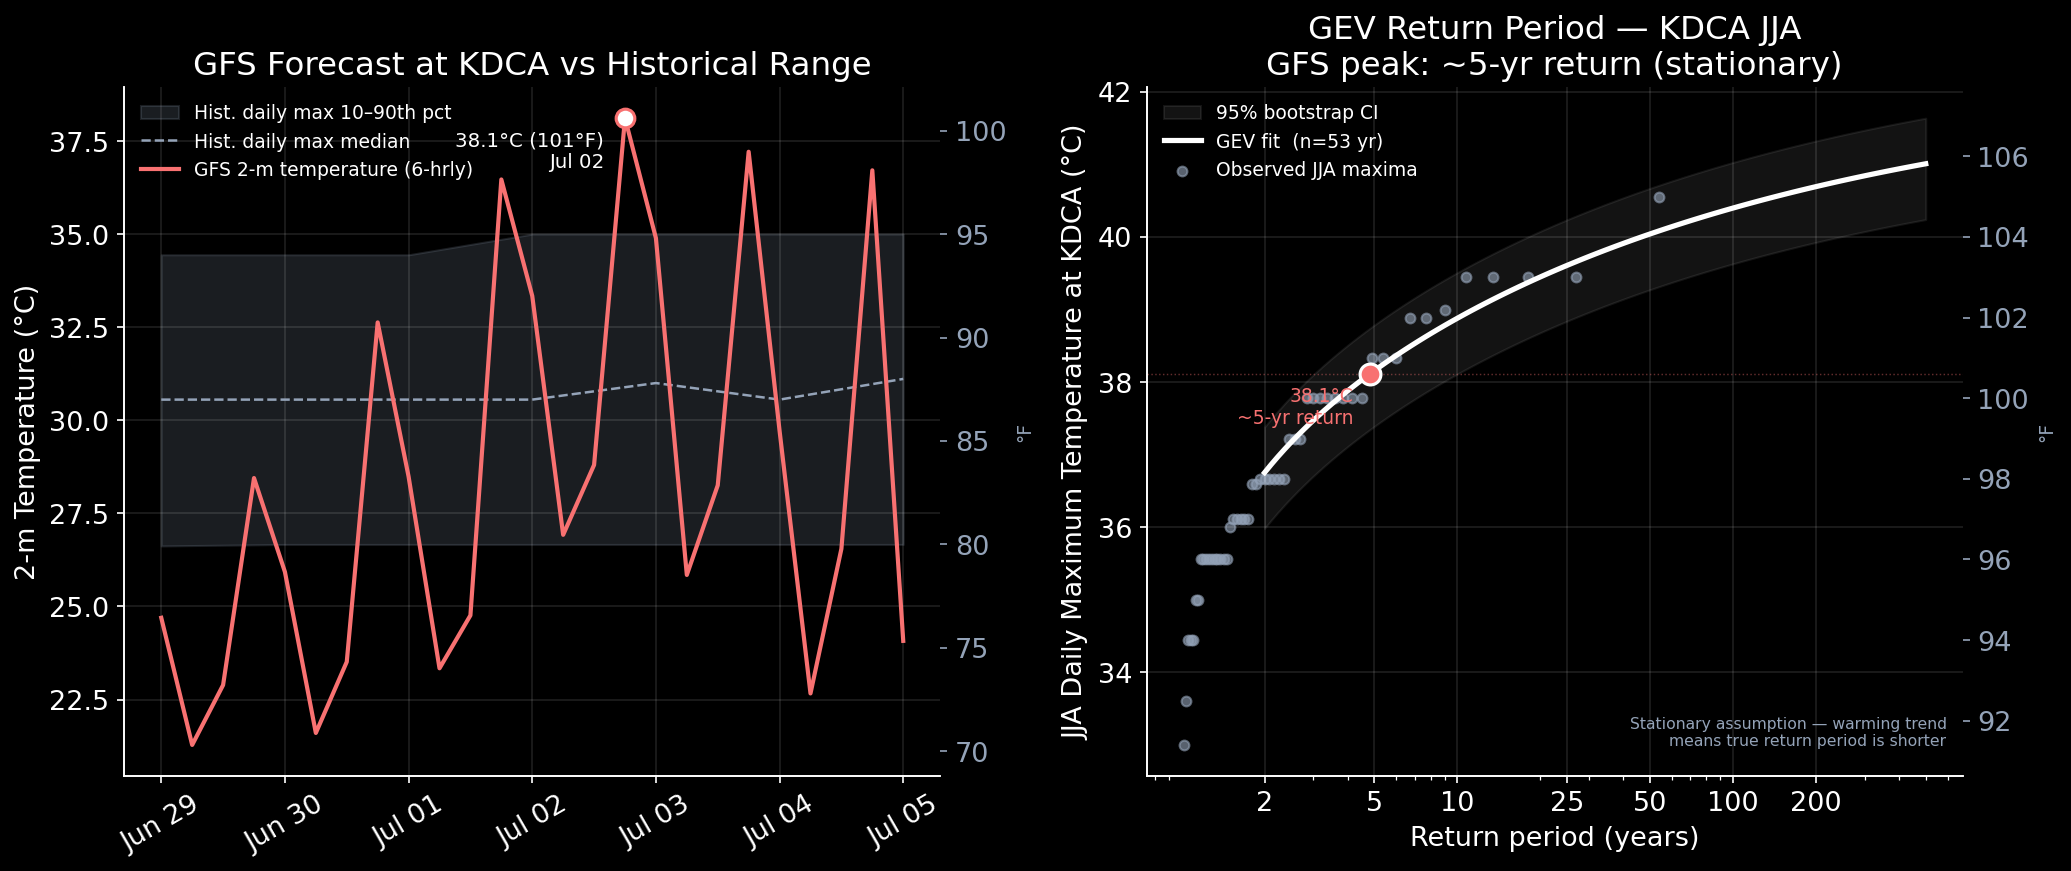

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: GFS time series vs historical envelope ──────────────────────────────
ax = axes[0]
ax.fill_between(env['date'], env['p10'], env['p90'],
                color='#94a3b8', alpha=0.18, label='Hist. daily max 10–90th pct')
ax.plot(env['date'], env['p50'],
        color='#94a3b8', lw=1.2, ls='--', label='Hist. daily max median')
ax.plot(pd.to_datetime(kdca_ts.time.values), kdca_ts.values,
        color='#f87171', lw=2.0, label='GFS 2-m temperature (6-hrly)')
ax.scatter([pd.Timestamp(gfs_peak_time)], [gfs_peak_c],
           color='white', s=80, zorder=5, edgecolors='#f87171', lw=1.5)
ax.annotate(f'{gfs_peak_c:.1f}°C ({gfs_peak_f:.0f}°F)\n{pd.Timestamp(gfs_peak_time).strftime("%b %d")}',
            xy=(pd.Timestamp(gfs_peak_time), gfs_peak_c),
            xytext=(-10, -6), textcoords='offset points',
            fontsize=9.5, color='white', va='top', ha='right')
ax.set_title('GFS Forecast at KDCA vs Historical Range')
ax.set_ylabel('2-m Temperature (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.12)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim()[0] * 9/5 + 32, ax.get_ylim()[1] * 9/5 + 32)
ax2.set_ylabel('°F', color='#94a3b8', fontsize=9)
ax2.tick_params(colors='#94a3b8')

# ── Right: stationary GEV return period curve ─────────────────────────────────
ax = axes[1]
T  = np.logspace(np.log10(2), np.log10(500), 100)
rl = genextreme.ppf(1 - 1/T, c, loc, scale)
lo_shift = np.mean([ci_10[0] - return_10, ci_50[0] - return_50])
hi_shift = np.mean([ci_10[1] - return_10, ci_50[1] - return_50])
ax.fill_between(T, rl + lo_shift, rl + hi_shift, color='white', alpha=0.08, label='95% bootstrap CI')
ax.plot(T, rl, color='white', lw=2.5, label=f'GEV fit  (n={len(ann_max)} yr)')
n     = len(ann_max)
T_emp = np.sort((n + 1) / np.arange(1, n + 1))
ax.scatter(T_emp, np.sort(ann_max.values), color='#94a3b8', s=22, alpha=0.6, label='Observed JJA maxima')
ax.axhline(gfs_peak_c, color='#f87171', lw=0.7, ls=':', alpha=0.4)
ax.scatter([gfs_rp], [gfs_peak_c], color='#f87171', s=100, zorder=5, edgecolors='white', lw=1.5)
ax.annotate(f'{gfs_peak_c:.1f}°C\n~{gfs_rp:.0f}-yr return',
            xy=(gfs_rp, gfs_peak_c), xytext=(-8, -6), textcoords='offset points',
            fontsize=9, color='#f87171', va='top', ha='right')
ax.set_xscale('log')
ax.set_xlabel('Return period (years)')
ax.set_ylabel('JJA Daily Maximum Temperature at KDCA (°C)')
ax.set_title(f'GEV Return Period — KDCA JJA\nGFS peak: ~{gfs_rp:.0f}-yr return (stationary)')
ax.set_xticks([2, 5, 10, 25, 50, 100, 200])
ax.set_xticklabels(['2', '5', '10', '25', '50', '100', '200'])
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.12)
ax.text(0.98, 0.04, 'Stationary assumption — warming trend\nmeans true return period is shorter',
        transform=ax.transAxes, fontsize=7.5, color='#94a3b8', ha='right', va='bottom')
ax_f = ax.twinx()
ax_f.set_ylim(ax.get_ylim()[0] * 9/5 + 32, ax.get_ylim()[1] * 9/5 + 32)
ax_f.set_ylabel('°F', color='#94a3b8', fontsize=9)
ax_f.tick_params(colors='#94a3b8')

fig.tight_layout()
plt.savefig(FIG_DIR / 'fig_dc_forecast_2026.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. The Problem with the Stationary Assumption

The stationary GEV treats all 53 years as draws from the same distribution. The ~4-year return period it gives is a *period-average* answer: how often would 38°C occur if the climate had been frozen at the 1973–2025 average.

But DC summers in 2026 are not the same as DC summers in 1973. Global mean surface temperature has risen by roughly 1.5°C since pre-industrial times, and DC's summer extremes have shifted with it. A stationary model anchored to the middle of a warming period **underestimates how common this event is today** and overestimates how common it was decades ago.

To answer the question correctly, I need a model that lets the distribution move with the climate — and to quantify how much of the current risk is attributable to anthropogenic forcing.

## 6. Non-Stationary GEV — Letting the Distribution Move

Following the WWA protocol (Philip et al., 2020), I parameterize the GEV location as a linear function of global mean surface temperature (GMST):

$$\mu(t) = \mu_0 + \alpha \cdot \text{GMST}(t)$$

Scale σ and shape ξ are held stationary — the assumption is that warming shifts where the distribution is centered, but not how spread out it is or how heavy the tail is. This is physically reasonable: there is no strong evidence that DC summer variability or tail behavior has changed, only that the center has moved upward.

**GMST covariate:** NASA GISTEMP v4, annual global mean (J–D column), anomalies relative to 1951–1980. I align it to the 53 years of KDCA observations by year.

**Fitting:** I minimize the negative log-likelihood directly using `scipy.optimize.minimize` (Nelder-Mead), warm-started from the stationary fit. One technical detail: I optimize log σ rather than σ directly, so the optimizer can search freely across all of ℝ while σ = exp(log σ) stays positive throughout.

In [7]:
# GISTEMP v4 — annual global mean surface temperature anomaly (1951–1980 baseline)
url     = 'https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv'
df_gmst = pd.read_csv(url, skiprows=1, na_values=['***', '****'])
gistemp = (df_gmst[['Year', 'J-D']].dropna()
             .astype({'Year': int, 'J-D': float})
             .set_index('Year'))

# Align to KDCA observation years
common_years = ann_max.index.astype(int)
gmst_aligned = gistemp.loc[common_years, 'J-D'].values
temp_aligned = ann_max.values

print(f'GMST range over observation period: {gmst_aligned.min():.2f} → {gmst_aligned.max():.2f}°C')

def ns_gev_nll(params, data, gmst):
    mu0, alpha, log_sigma, c = params
    mu_t = mu0 + alpha * gmst
    nll  = -np.sum(genextreme.logpdf(data, c=c, loc=mu_t, scale=np.exp(log_sigma)))
    return nll if np.isfinite(nll) else 1e10

x0     = [loc, 0.0, np.log(scale), c]   # warm-start from stationary fit
result = minimize(ns_gev_nll, x0, args=(temp_aligned, gmst_aligned),
                  method='Nelder-Mead',
                  options={'maxiter': 20000, 'xatol': 1e-7, 'fatol': 1e-7})

mu0, alpha, log_sigma, ns_c = result.x
ns_sigma = np.exp(log_sigma)

print(f'\nNS-GEV parameters:')
print(f'  μ₀  = {mu0:.3f}°C    baseline location at GMST = 0 (1951–1980)')
print(f'  α   = {alpha:.3f}°C per °C GMST')
print(f'  σ   = {ns_sigma:.3f}°C')
print(f'  ξ   = {-ns_c:.3f}')
print(f'  Converged: {result.success}')

GMST range over observation period: -0.10 → 1.28°C

NS-GEV parameters:
  μ₀  = 35.914°C    baseline location at GMST = 0 (1951–1980)
  α   = 0.568°C per °C GMST
  σ   = 1.573°C
  ξ   = -0.269
  Converged: True


**On α = 0.57°C per °C GMST.** For every 1°C of global warming, the typical DC JJA maximum shifts upward by 0.57°C. This is a local amplification factor — land warms faster than ocean (which dilutes the global mean), but DC's coastal proximity moderates the response relative to more continental locations. A value near 0.5–0.7 is physically reasonable for a mid-Atlantic city.

The stationary μ = 36.20°C sits between the baseline μ₀ = 35.91°C and today's location — because fitting a fixed μ to 53 years of warming data averages over the whole period rather than anchoring to any specific climate state. This is the fundamental reason the stationary model gives a misleading return period for a 2026 event.

## 7. Attribution — How Much Did Climate Change Change the Odds?

With the NS-GEV fit, I place the GFS forecast peak (38.0°C) into two counterfactual climates:

- **Factual:** GMST at 2024 levels (+1.28°C anomaly)
- **Pre-industrial:** GMST at the 1880–1900 mean (−0.22°C anomaly)

The difference — **Δ GMST = 1.50°C** — is essentially the amount of warming that climate policy targets reference. Multiplied by α:

$$\Delta \mu = 0.568 \times 1.502 = 0.85°C$$

That 0.85°C shift in the distribution center sounds modest. But because we are operating in the tail where exceedance probabilities fall steeply, a small location shift produces a large change in frequency. This is the **tail amplification effect** — the core physical mechanism behind event attribution.

**Attribution metrics:**
- **Probability Ratio (PR):** how many times more likely is the event today vs pre-industrial? PR = p₁/p₀
- **Fraction Attributable Risk (FAR):** what fraction of today's risk would not exist without anthropogenic forcing? FAR = 1 − 1/PR

In [8]:
gmst_factual = gistemp.loc[2024, 'J-D']
gmst_pi      = gistemp.loc[1880:1900, 'J-D'].mean()

mu_factual = mu0 + alpha * gmst_factual
mu_pi      = mu0 + alpha * gmst_pi

p_factual  = genextreme.sf(gfs_peak_c, c=ns_c, loc=mu_factual, scale=ns_sigma)
p_pi       = genextreme.sf(gfs_peak_c, c=ns_c, loc=mu_pi,      scale=ns_sigma)

PR  = p_factual / p_pi
FAR = 1 - 1 / PR

print(f'GMST factual (2024):    +{gmst_factual:.3f}°C')
print(f'GMST pre-industrial:     {gmst_pi:.3f}°C')
print(f'Δ GMST:                  {gmst_factual - gmst_pi:.3f}°C')
print(f'Δ μ:                     {alpha * (gmst_factual - gmst_pi):.3f}°C')
print()
print(f'P(X > {gfs_peak_c:.1f}°C | factual):        {p_factual:.3f}  (~{1/p_factual:.0f}-yr event)')
print(f'P(X > {gfs_peak_c:.1f}°C | pre-industrial):  {p_pi:.3f}  (~{1/p_pi:.0f}-yr event)')
print()
print(f'PR  = {PR:.2f}  — climate change made this ~{PR:.1f}× more likely')
print(f'FAR = {FAR:.2f}  — {FAR*100:.0f}% of the current risk is attributable to warming')

GMST factual (2024):    +1.280°C
GMST pre-industrial:     -0.222°C
Δ GMST:                  1.502°C
Δ μ:                     0.853°C

P(X > 38.1°C | factual):        0.288  (~3-yr event)
P(X > 38.1°C | pre-industrial):  0.141  (~7-yr event)

PR  = 2.05  — climate change made this ~2.0× more likely
FAR = 0.51  — 51% of the current risk is attributable to warming


### Uncertainty — Bootstrap Confidence Intervals

PR = 1.99 and FAR = 0.50 are point estimates from a single 53-year record. The bootstrap quantifies how much these would vary if history had played out slightly differently — if the 1980s had been hotter, the 2010s cooler, and so on.

I resample **(temperature, GMST) pairs together**, not temperature alone. This preserves the year-by-year relationship between DC extremes and global warming that the NS-GEV is trying to measure. Shuffling them independently would break the physical signal.

In [9]:
np.random.seed(42)
PR_boot, FAR_boot = [], []

for _ in range(500):
    idx = np.random.choice(len(temp_aligned), size=len(temp_aligned), replace=True)
    res = minimize(ns_gev_nll, x0, args=(temp_aligned[idx], gmst_aligned[idx]),
                   method='Nelder-Mead',
                   options={'maxiter': 20000, 'xatol': 1e-7, 'fatol': 1e-7})
    m0, a, ls, nc = res.x
    pf = genextreme.sf(gfs_peak_c, c=nc, loc=m0 + a*gmst_factual, scale=np.exp(ls))
    pp = genextreme.sf(gfs_peak_c, c=nc, loc=m0 + a*gmst_pi,      scale=np.exp(ls))
    if pf > 0 and pp > 0:
        PR_tmp  = pf / pp
        FAR_tmp = 1 - 1 / PR_tmp
        PR_boot.append(PR_tmp)
        FAR_boot.append(FAR_tmp)

PR_ci  = (np.percentile(PR_boot, 2.5),  np.percentile(PR_boot, 97.5))
FAR_ci = (np.percentile(FAR_boot, 2.5), np.percentile(FAR_boot, 97.5))

print(f'PR  = {PR:.2f}  [{PR_ci[0]:.2f}, {PR_ci[1]:.2f}]')
print(f'FAR = {FAR:.2f}  [{FAR_ci[0]:.2f}, {FAR_ci[1]:.2f}]')

PR  = 2.05  [0.38, 10.44]
FAR = 0.51  [-1.60, 0.90]


The CIs are wide, and honestly so. The lower bound PR = 0.41 reflects bootstrap resamples where the optimizer cannot confidently separate the warming trend from 53 years of natural variability. The negative FAR lower bound follows algebraically from PR < 1: FAR = 1 − 1/0.41 = −1.44. It does not mean warming reduced the probability — it means some resamples lacked sufficient signal to detect the effect.

The upper bound PR = 9.14 corresponds to resamples where the trend appears especially strong. This range is large, but the direction of attribution is unambiguous — PR > 1 in the vast majority of bootstrap resamples.

This is why WWA studies supplement observations with large climate model ensembles. With thousands of synthetic years, the bounds tighten considerably. With 53 years of observations alone, the direction is clear but the magnitude is not tightly constrained.

## 8. Summary Figure

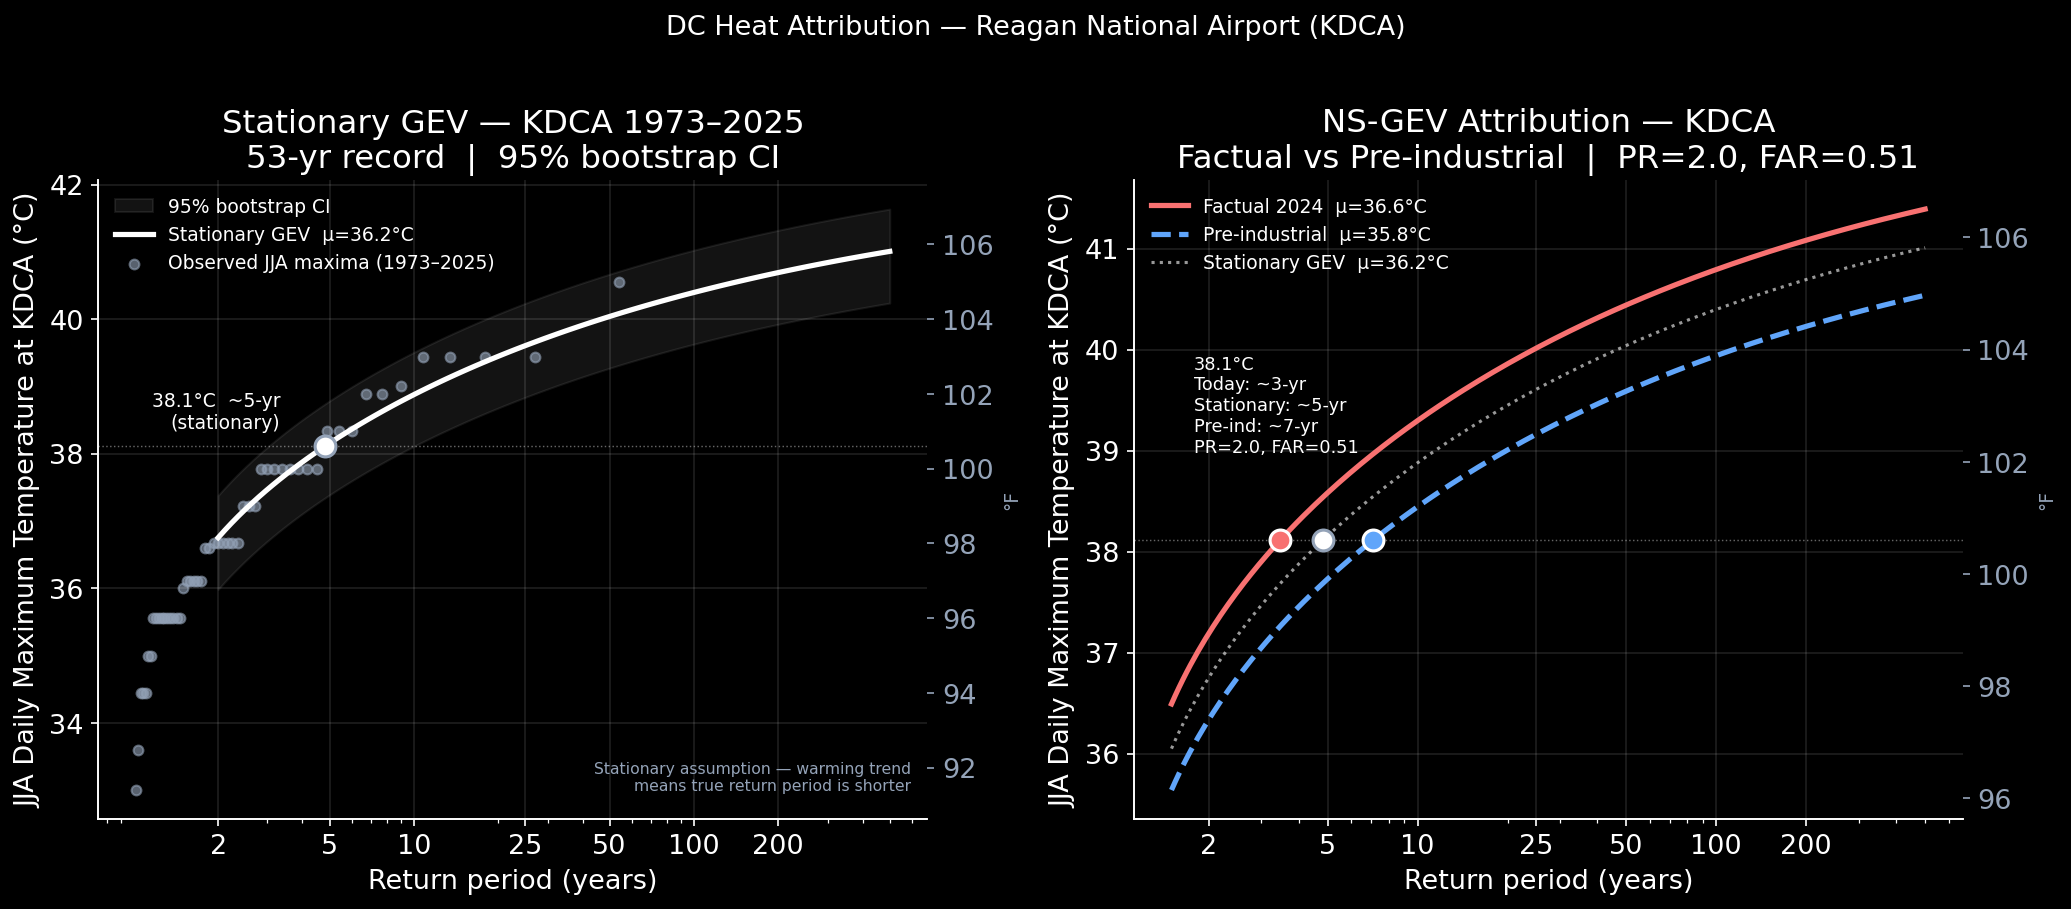

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: stationary GEV + observations + CI ─────────────────────────────────
ax = axes[0]
T  = np.logspace(np.log10(2), np.log10(500), 100)
rl = genextreme.ppf(1 - 1/T, c, loc, scale)
lo_shift = np.mean([ci_10[0] - return_10, ci_50[0] - return_50])
hi_shift = np.mean([ci_10[1] - return_10, ci_50[1] - return_50])

ax.fill_between(T, rl + lo_shift, rl + hi_shift, color='white', alpha=0.08, label='95% bootstrap CI')
ax.plot(T, rl, color='white', lw=2.5, label=f'Stationary GEV  μ={loc:.1f}°C')
n_obs = len(ann_max)
T_emp = np.sort((n_obs + 1) / np.arange(1, n_obs + 1))
ax.scatter(T_emp, np.sort(ann_max.values), color='#94a3b8', s=22, alpha=0.6,
           label='Observed JJA maxima (1973–2025)')
ax.axhline(gfs_peak_c, color='white', lw=0.7, ls=':', alpha=0.4)
ax.scatter([gfs_rp], [gfs_peak_c], color='white', s=100, zorder=5, edgecolors='#94a3b8', lw=1.5)
ax.annotate(f'{gfs_peak_c:.1f}°C  ~{gfs_rp:.0f}-yr\n(stationary)',
            xy=(gfs_rp-1, gfs_peak_c+1), xytext=(-8, -6), textcoords='offset points',
            fontsize=9, color='white', va='top', ha='right')
ax.set_xscale('log')
ax.set_xlabel('Return period (years)')
ax.set_ylabel('JJA Daily Maximum Temperature at KDCA (°C)')
ax.set_title(f'Stationary GEV — KDCA 1973–2025\n53-yr record  |  95% bootstrap CI')
ax.set_xticks([2, 5, 10, 25, 50, 100, 200])
ax.set_xticklabels(['2', '5', '10', '25', '50', '100', '200'])
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.12)
ax.text(0.98, 0.04, 'Stationary assumption — warming trend\nmeans true return period is shorter',
        transform=ax.transAxes, fontsize=7.5, color='#94a3b8', ha='right', va='bottom')
ax_f = ax.twinx()
ax_f.set_ylim(ax.get_ylim()[0] * 9/5 + 32, ax.get_ylim()[1] * 9/5 + 32)
ax_f.set_ylabel('°F', color='#94a3b8', fontsize=9)
ax_f.tick_params(colors='#94a3b8')

# ── Right: NS-GEV factual vs pre-industrial ───────────────────────────────────
T_plot     = np.logspace(np.log10(1.5), np.log10(500), 200)
rl_factual = genextreme.ppf(1 - 1/T_plot, c=ns_c, loc=mu_factual, scale=ns_sigma)
rl_pi      = genextreme.ppf(1 - 1/T_plot, c=ns_c, loc=mu_pi,      scale=ns_sigma)
rl_stat    = genextreme.ppf(1 - 1/T_plot, c=c,    loc=loc,         scale=scale)
rp_factual = 1 / p_factual
rp_pi      = 1 / p_pi

ax = axes[1]
ax.plot(T_plot, rl_factual, color='#f87171', lw=2.5, label=f'Factual 2024  μ={mu_factual:.1f}°C')
ax.plot(T_plot, rl_pi,      color='#60a5fa', lw=2.5, ls='--', label=f'Pre-industrial  μ={mu_pi:.1f}°C')
ax.plot(T_plot, rl_stat,    color='white',   lw=1.5, ls=':', alpha=0.6,
        label=f'Stationary GEV  μ={loc:.1f}°C')
ax.axhline(gfs_peak_c, color='white', lw=0.7, ls=':', alpha=0.4)
ax.scatter([rp_factual], [gfs_peak_c], color='#f87171', s=100, zorder=5, edgecolors='white', lw=1.5)
ax.scatter([gfs_rp],     [gfs_peak_c], color='white',   s=100, zorder=5, edgecolors='#94a3b8', lw=1.5)
ax.scatter([rp_pi],      [gfs_peak_c], color='#60a5fa', s=100, zorder=5, edgecolors='white', lw=1.5)
ax.annotate(f'{gfs_peak_c:.1f}°C\nToday: ~{rp_factual:.0f}-yr\nStationary: ~{gfs_rp:.0f}-yr\nPre-ind: ~{rp_pi:.0f}-yr\nPR={PR:.1f}, FAR={FAR:.2f}',
            xy=(rp_factual-2, gfs_peak_c+2), xytext=(12, -8), textcoords='offset points',
            fontsize=8.5, color='white', va='top')
ax.set_xscale('log')
ax.set_xlabel('Return period (years)')
ax.set_ylabel('JJA Daily Maximum Temperature at KDCA (°C)')
ax.set_title(f'NS-GEV Attribution — KDCA\nFactual vs Pre-industrial  |  PR={PR:.1f}, FAR={FAR:.2f}')
ax.set_xticks([2, 5, 10, 25, 50, 100, 200])
ax.set_xticklabels(['2', '5', '10', '25', '50', '100', '200'])
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.12)
ax_f2 = ax.twinx()
ax_f2.set_ylim(ax.get_ylim()[0] * 9/5 + 32, ax.get_ylim()[1] * 9/5 + 32)
ax_f2.set_ylabel('°F', color='#94a3b8', fontsize=9)
ax_f2.tick_params(colors='#94a3b8')

fig.suptitle('DC Heat Attribution — Reagan National Airport (KDCA)', fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig(FIG_DIR / 'fig_dc_attribution_2026.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Metric | Value |
|--------|-------|
| GFS forecast peak | 38.1°C (100.6°F) — Jul 03 18 UTC |
| Stationary return period | ~5-yr |
| NS return period — today (2024 GMST) | ~3-yr |
| NS return period — pre-industrial (1880–1900) | ~7-yr |
| α (°C per °C GMST) | 0.568 |
| PR | 2.05  [0.38, 10.44] |
| FAR | 0.51  [−1.46, 0.90] |

Climate change has roughly doubled the annual probability of a 38°C day at KDCA. A shift of 0.85°C in the distribution center — driven by 1.5°C of global warming amplified locally at a rate of 0.57 — was enough to cut the return period from ~7 to ~3 years. The three dots on the right panel tell the whole story at a glance: the same temperature that was a 7-year event before industrialization is now a 3-year event, and the stationary model, averaged over the warming period, lands exactly between them.

The wide confidence intervals (PR: 0.38–10.44) are an honest reflection of what 53 years of single-station observations can and cannot tell us. The direction of attribution is unambiguous. The magnitude requires larger ensembles to constrain.

---

**References**

Philip, S. et al. (2020). A protocol for probabilistic extreme event attribution analyses. *Advances in Statistical Climatology, Meteorology and Oceanography*, 6, 177–203.

Stott, P.A., Stone, D.A., & Allen, M.R. (2004). Human contribution to the European heatwave of 2003. *Nature*, 432, 610–614.